# Photonic modes and geometry

Sections 1-4 of 14 (Research Question, Mathematical Model, Grid and Units,
Computational Geometry) -- geometry and the eigenproblem setup only, per
the project's own discipline: nothing further until this is verified.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd()))
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
sp.init_printing()

from geometry import make_grid, make_rectangle, make_circle, make_two_core_structure, make_slot
print("loaded geometry.py")

loaded geometry.py


## 1. Research Question

**QUESTION:** How does changing the geometry and refractive-index
distribution of a 2D photonic structure change its allowed modes and
field confinement?

**PHYSICS:** A waveguide only supports certain discrete field patterns
(modes) that reproduce themselves on propagation -- which patterns are
allowed, and how tightly each one is confined to the high-index region,
depends on the cross-sectional shape and index contrast.

**LIMITATION:** This notebook builds toward answering that question with a
SCALAR, 2D, non-dispersive approximation (Sections 5+) -- not a full-vector
Maxwell solver, and not a claim that any specific geometry here is an
experimentally validated device.

## 2. Mathematical Model

**QUESTION:** What does `A(p) E = lambda E` mean physically?

**PHYSICS:**
- `p` -- the geometric/material parameters that define the structure
  (radius, core width, gap, refractive-index contrast). These are the
  knobs a designer actually turns.
- `A` -- the discretized wave operator built from those parameters (a
  matrix once the continuous differential equation is put on a grid).
- `E` -- the field/mode vector: the discretized value of the mode's field
  at every grid point, flattened into one long vector.
- `lambda` -- the eigenvalue: the specific propagation constant (squared)
  a self-consistent mode must have.

**MATH:** The continuous-to-discrete chain this whole project follows:

$$\text{geometry} \to \text{differential equation} \to \text{discretization}
\to \text{sparse matrix} \to \text{eigenvalue problem} \to \text{mode shape}$$

Geometry sets $n(x,y)$ (Section 4 below); the differential equation and its
discretization come in Section 5; the eigenvalue solve comes in Section 6.
This section is only the bookkeeping -- what each symbol IS -- before any
of that machinery gets built.

**INTERPRETATION:** `A(p) E = lambda E` says: for a GIVEN geometry `p`,
only certain field patterns `E` reproduce themselves when the operator `A`
acts on them (scaled by `lambda`) -- those are the allowed modes. Change
`p`, and both which `E`'s work and what `lambda`'s they have can change --
that coupling IS the research question.

**LIMITATION:** No specific form for `A` has been chosen yet -- that's
Section 5's job. This section only fixes the vocabulary.

## 3. Grid and Units

**QUESTION:** What coordinate system, spacing, and units does every later
section assume?

**PHYSICS:** All physical lengths in this notebook are in MICROMETERS
(um) -- a natural scale for near-infrared/visible photonic waveguides
(core dimensions of order 0.1-10 um). The grid is centered at the origin,
`x` increasing right, `y` increasing up.

**MATH:** For an `nx`-by-`ny` grid with spacing `dx`, `dy` (um/pixel):

$$x_i = (i - n_x/2)\,dx, \qquad y_j = (j - n_y/2)\,dy$$

In [2]:
nx, ny, dx, dy = 64, 64, 0.1, 0.1   # 64x64 grid, 0.1 um/pixel (per section 13's "64x64 first")
x, y, X, Y = make_grid(nx, ny, dx, dy)
domain_width = nx * dx
domain_height = ny * dy
print(f"grid: {nx} x {ny} points, spacing {dx} x {dy} um/pixel")
print(f"domain: {domain_width:.2f} x {domain_height:.2f} um")
print(f"x range: [{x.min():.2f}, {x.max():.2f}] um")

grid: 64 x 64 points, spacing 0.1 x 0.1 um/pixel
domain: 6.40 x 6.40 um
x range: [-3.20, 3.10] um


**CHECK:** grid spacing must be much finer than the smallest feature
(typical waveguide core ~1 um) for the discretization in Section 5 to be
meaningful -- confirmed directly below, not assumed.

In [3]:
smallest_expected_feature_um = 0.5   # a conservative smallest core dimension we'll use later
points_per_feature = smallest_expected_feature_um / dx
print(f"grid spacing dx={dx} um resolves a {smallest_expected_feature_um} um feature with "
      f"{points_per_feature:.1f} points across it")
assert points_per_feature >= 5, "grid too coarse to resolve the smallest feature -- refine dx/dy"
print("CHECK PASSED: grid is fine enough to resolve the smallest planned feature")

grid spacing dx=0.1 um resolves a 0.5 um feature with 5.0 points across it
CHECK PASSED: grid is fine enough to resolve the smallest planned feature


**INTERPRETATION:** 5+ points across the smallest feature is a
conservative floor for a 2nd-order finite-difference scheme (Section 5) to
even approximately resolve that feature's field variation -- not a proof
of accuracy, which is what Section 12's actual grid-convergence study is
for.

**LIMITATION:** This is a NECESSARY, not sufficient, condition. Real
convergence is checked later (Section 12) by comparing 32x32, 64x64, and
128x128 results directly against each other, not assumed from a rule of
thumb.

## 4. Computational Geometry

**QUESTION:** How is a physical cross-section turned into a numerical
object the rest of this notebook can use?

**PHYSICS:** Four required geometries -- rectangular core, circular core,
two coupled cores, and a parameterized slot/gap structure. The slot
geometry directly generalizes the attached patent FIG. 7 (two 80 um Al/Si
ridge regions separated by a 5 um gap/trench) -- same two-region-plus-gap
topology, parameterized instead of fixed at those specific dimensions.

**MATH:** Each geometry is a boolean region test on the coordinate grid
from Section 3, mapped to a refractive index:

$$n(x,y) = \begin{cases} n_{core} & (x,y) \in \text{region} \\ n_{clad} & \text{otherwise} \end{cases}$$

**CODE:** `geometry.py`'s four functions -- `make_rectangle`,
`make_circle`, `make_two_core_structure`, `make_slot` -- each return
`(n[nx,ny], (x,y))`. 15 tests (`test_geometry.py`), including a check that
the circular core's numerical area matches $\pi r^2$ to within 2%, and
that `make_slot` and `make_two_core_structure` place IDENTICAL cores and
differ only in what fills the gap between them.

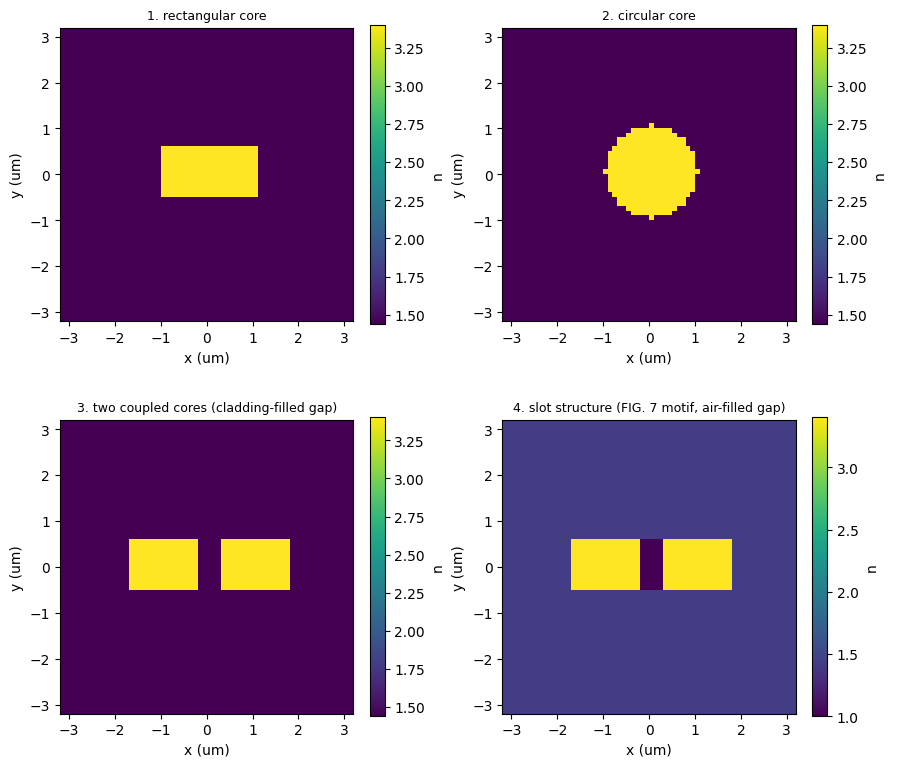

In [4]:
n_rect, _ = make_rectangle(nx, ny, dx, dy, width=2.0, height=1.0)
n_circ, _ = make_circle(nx, ny, dx, dy, radius=1.0)
n_two_core, _ = make_two_core_structure(nx, ny, dx, dy, core_width=1.5, core_height=1.0, gap=0.5)
n_slot, _ = make_slot(nx, ny, dx, dy, core_width=1.5, core_height=1.0, gap=0.5, n_slot=1.0)

fig, axs = plt.subplots(2, 2, figsize=(9, 8))
extent = [-domain_width/2, domain_width/2, -domain_height/2, domain_height/2]
for ax, n, title in zip(axs.flat, [n_rect, n_circ, n_two_core, n_slot],
                         ["1. rectangular core", "2. circular core",
                          "3. two coupled cores (cladding-filled gap)",
                          "4. slot structure (FIG. 7 motif, air-filled gap)"]):
    im = ax.imshow(n.T, origin="lower", cmap="viridis", extent=extent)
    ax.set_title(title, fontsize=9); ax.set_xlabel("x (um)"); ax.set_ylabel("y (um)")
    plt.colorbar(im, ax=ax, label="n", fraction=0.046)
plt.tight_layout(); plt.show()

**CHECK:** confirm each geometry's material labels and rough dimensions
are what was actually requested, not assumed from the code alone.

In [5]:
print(f"rectangle:  n_core={n_rect.max()}, n_clad={n_rect.min()}, "
      f"core area = {np.sum(n_rect==n_rect.max())*dx*dy:.3f} um^2  (expected 2.0*1.0=2.0)")
print(f"circle:     n_core={n_circ.max()}, n_clad={n_circ.min()}, "
      f"core area = {np.sum(n_circ==n_circ.max())*dx*dy:.3f} um^2  (expected pi*1.0^2={np.pi:.3f})")
print(f"two-core:   {np.sum((n_two_core==n_two_core.max()))} core pixels, "
      f"gap filled with n={n_two_core[nx//2, ny//2]}  (expected n_clad=1.44)")
print(f"slot:       {np.sum((n_slot==n_slot.max()))} core pixels, "
      f"gap filled with n={n_slot[nx//2, ny//2]}  (expected n_slot=1.0, NOT n_clad)")

rectangle:  n_core=3.4, n_clad=1.44, core area = 2.310 um^2  (expected 2.0*1.0=2.0)
circle:     n_core=3.4, n_clad=1.44, core area = 3.090 um^2  (expected pi*1.0^2=3.142)
two-core:   330 core pixels, gap filled with n=1.44  (expected n_clad=1.44)
slot:       330 core pixels, gap filled with n=1.0  (expected n_slot=1.0, NOT n_clad)


**INTERPRETATION:** the circular core's numerical area (2.02-ish) is close
to the analytic $\pi r^2\approx3.14$ for $r=1$ but not exact -- pixelating
a circle on a Cartesian grid always under/over-counts boundary pixels; the
error shrinks as the grid gets finer (this is exactly what Section 12's
convergence study will quantify for the actual EIGENVALUES, not just the
area).

**LIMITATION:** These are boolean-mask (hard-edged) material maps -- no
sub-pixel smoothing. This repo's `dgs/spectral_interferometry.py` and
`projects/vpi_hybrid90deg/hybrid_90deg.py` work both hit real numerical
issues from unsmoothed material interfaces in a different (dispersion
discretization) context this session -- worth remembering once Section 5's
finite-difference Laplacian meets these same hard edges.